In [1]:
import pypowsybl.network as pn
import pypowsybl as pp
import pypowsybl.dynamic as dyn
from pypowsybl_jupyter import display_nad
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [ ]:
from helpers import *

In [3]:
UNom = 1
SnRef = 100.0
puCoeff = UNom * UNom / SnRef

network = pn.create_empty()

network.create_substations(
    id=["S1", "S2"], name=["S1", "S2"], country=["FR", "FR"], tso=["SMIB", "SMIB"]
)

network.create_voltage_levels(
    id="VL1",
    name="VL1",
    substation_id="S1",
    topology_kind="BUS_BREAKER",
    nominal_v=1 * UNom,
    low_voltage_limit=0.8 * UNom,
    high_voltage_limit=1.2 * UNom,
)
network.create_voltage_levels(
    id="VL2",
    name="VL2",
    substation_id="S2",
    topology_kind="BUS_BREAKER",
    nominal_v=1 * UNom,
    low_voltage_limit=0.8 * UNom,
    high_voltage_limit=1.2 * UNom,
)
network.create_voltage_levels(
    id="VL3",
    name="VL3",
    substation_id="S2",
    topology_kind="BUS_BREAKER",
    nominal_v=1 * UNom,
    low_voltage_limit=0.8 * UNom,
    high_voltage_limit=1.2 * UNom,
)

network.create_buses(id="VL1_BUS1", voltage_level_id="VL1")

network.create_buses(id="VL2_BUS1", voltage_level_id="VL2")

network.create_buses(id="VL3_BUS1", voltage_level_id="VL3")

network.create_lines(
    id="line1",
    voltage_level1_id="VL1",
    bus1_id="VL1_BUS1",
    voltage_level2_id="VL2",
    bus2_id="VL2_BUS1",
    b1=0,
    b2=0,
    g1=0,
    g2=0,
    r=0,
    x=0.022522 * puCoeff,
)

network.create_lines(
    id="line2",
    voltage_level1_id="VL1",
    bus1_id="VL1_BUS1",
    voltage_level2_id="VL2",
    bus2_id="VL2_BUS1",
    b1=0,
    b2=0,
    g1=0,
    g2=0,
    r=0,
    x=0.04189 * puCoeff,
)

network.create_2_windings_transformers(
    id="TR",
    voltage_level1_id="VL2",
    bus1_id="VL2_BUS1",
    voltage_level2_id="VL3",
    bus2_id="VL3_BUS1",
    b=0,
    g=0,
    r=0,
    x=0.00675 * puCoeff,
    rated_u1=1,
    rated_u2=1,
)

network.create_generators(
    id="SM",
    voltage_level_id="VL3",
    bus_id="VL3_BUS1",
    target_p=1998,
    min_p=0,
    max_p=2220,
    target_q=967.903359,
    energy_source="NUCLEAR",
    voltage_regulator_on=False,
)

network.create_generators(
    id="InfiniteBus",
    voltage_level_id="VL1",
    bus_id="VL1_BUS1",
    target_p=0,
    min_p=-10000,
    max_p=10000,
    target_v=1 * UNom,
    voltage_regulator_on=True,
)
network.update_generators(id="InfiniteBus", regulated_element_id="SM")

parameters = pp.loadflow.Parameters(
    distributed_slack=False,
    provider_parameters={
        "slackBusSelectionMode": "NAME",
        "slackBusesIds": "VL1_0",
        "voltageRemoteControl": "true",
    },
)  # Do not compensate slack_bus imbalance
result = pp.loadflow.run_ac(network, parameters=parameters, provider="OpenLoadFlow")
network.update_generators(id="InfiniteBus", p=0, q=0)

filename_out = "smib_infiniteBus.xiidm"
network.save(filename_out, format="XIIDM", parameters={"iidm.export.xml.version": "1.4"})
fixIIDMSourceFormat(filename_out)

In [4]:
display_nad(network.get_network_area_diagram())

NadWidget(diagram_data={'svg_data': '<?xml version="1.0" encoding="UTF-8"?>\n<svg width="379.96" height="600.0…

In [5]:
model_mapping = dyn.ModelMapping()

# model_mapping.add_infinite_bus(static_id='InfiniteBus', parameter_set_id='InfiniteBus', model_name='InfiniteBus')
# model_mapping.add_base_bus(static_id='VL1_BUS1', parameter_set_id='bus1', model_name='Bus')

model_mapping.add_infinite_bus(
    static_id="VL1_BUS1", parameter_set_id="InfiniteBus", model_name="InfiniteBus"
)
model_mapping.add_base_generator(
    static_id="InfiniteBus",
    parameter_set_id="InfiniteBusGen",
    model_name="GeneratorFictitious",
)

model_mapping.add_base_bus(static_id="VL2_BUS1", parameter_set_id="bus1", model_name="Bus")
model_mapping.add_base_bus(static_id="VL3_BUS1", parameter_set_id="bus2", model_name="Bus")

model_mapping.add_base_line(static_id="line1", parameter_set_id="line1", model_name="Line")
model_mapping.add_base_line(static_id="line2", parameter_set_id="line2", model_name="Line")

model_mapping.add_base_transformer(
    static_id="TR", parameter_set_id="TR", model_name="TransformerFixedRatio"
)

model_mapping.add_synchronous_generator(
    static_id="SM",
    parameter_set_id="SM",
    model_name="GeneratorSynchronousFourWindingsProportionalRegulations",
)

In [6]:
event_mapping = dyn.EventMapping()
event_mapping.add_active_power_variation(static_id="SM", start_time=1, delta_p=0.02)

In [7]:
variables_mapping = dyn.OutputVariableMapping()
variables_mapping.add_dynamic_model_curves("SM", "generator_PGen")

In [8]:
network2 = pn.load(filename_out)
sim = dyn.Simulation()
res = sim.run(network2, model_mapping, event_mapping, variables_mapping, 0, 30)

In [9]:
print(res.status())

DynamicSimulationStatus.SUCCESS


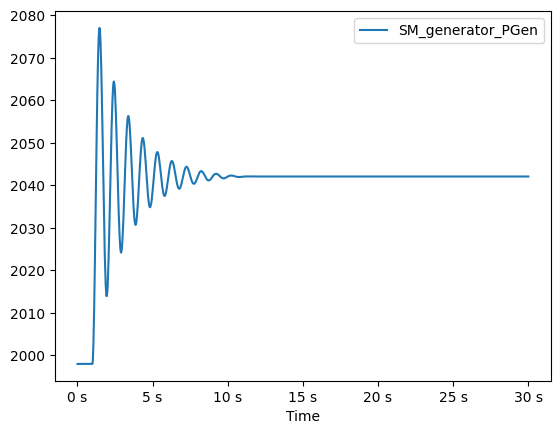

In [10]:
plot(res.curves())